# Marketplace Revenue Forecasting & Predictive Analytics

## Project Overview

This notebook focuses on predictive analytics and revenue forecasting workflows using synthetic marketplace transaction data.

The objective of this analysis is to:
- forecast future marketplace revenue trends
- identify variables influencing GMV behavior
- evaluate seasonality-driven purchasing patterns
- simulate operational forecasting workflows commonly used in ecommerce and marketplace analytics environments

The forecasting workflow incorporates:
- feature engineering
- seasonal trend analysis
- predictive modeling
- model evaluation
- operational forecasting concepts
- business-oriented predictive analytics

---

## Forecasting Objectives

The primary forecasting objectives include:

1. Forecast future marketplace revenue behavior.
2. Identify variables influencing marketplace GMV performance.
3. Evaluate the impact of seasonal and operational factors on transaction activity.
4. Simulate predictive analytics workflows for operational planning.
5. Support future inventory and staffing forecasting decisions.
6. Compare forecasting model performance across predictive techniques.

---

## Predictive Analytics Workflow

The forecasting workflow for this notebook includes:

1. Data loading and preparation  
2. Revenue aggregation and feature engineering  
3. Seasonal and operational variable analysis  
4. Forecast dataset preparation  
5. Predictive model training  
6. Revenue prediction generation  
7. Forecast evaluation and visualization  
8. Business forecasting insights and strategic recommendations  

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Linear Regression
- Random Forest Regression

---

## Dataset Description

The forecasting dataset contains:
- historical marketplace transaction revenue
- seasonal calendar factors
- holiday indicators
- temperature-related variables
- weekend purchasing behavior
- marketplace search demand indicators

The dataset was designed to simulate predictive analytics workflows commonly used in marketplace operations, ecommerce strategy, and business intelligence forecasting environments.

In [37]:
 # ------------------------------------------------------------
# Marketplace Forecasting & Predictive Analytics
# Step 1: Import Libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [38]:
# ------------------------------------------------------------
# Step 2: Load Marketplace Datasets
# ------------------------------------------------------------

sales = pd.read_csv("sales.csv")
calendar = pd.read_csv("calendar_factors.csv")
search_trends = pd.read_csv("search_trends.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [39]:
# ------------------------------------------------------------
# Step 3: Prepare Revenue Dataset
# ------------------------------------------------------------

sales["sale_date"] = pd.to_datetime(
    sales["sale_date"]
)

daily_revenue = (
    sales
    .groupby("sale_date")["revenue"]
    .sum()
    .reset_index()
)

daily_revenue.head()

,sale_date,revenue
0,2023-01-01,"5,911.79"
1,2023-01-02,"3,699.10"
2,2023-01-03,"3,737.85"
3,2023-01-04,"3,468.32"
4,2023-01-05,"3,328.10"


In [40]:
# ------------------------------------------------------------
# Step 4: Merge Forecasting Features
# ------------------------------------------------------------

calendar["calendar_date"] = pd.to_datetime(calendar["calendar_date"])

forecast_data = daily_revenue.merge(
    calendar,
    left_on="sale_date",
    right_on="calendar_date",
    how="left"
)

forecast_data.head()

,sale_date,revenue,calendar_date,year,month,day_of_week,season,is_weekend,is_holiday,temperature
0,2023-01-01,"5,911.79",2023-01-01,2023,1,Sunday,Winter,1,1,45
1,2023-01-02,"3,699.10",2023-01-02,2023,1,Monday,Winter,0,0,41
2,2023-01-03,"3,737.85",2023-01-03,2023,1,Tuesday,Winter,0,0,46
3,2023-01-04,"3,468.32",2023-01-04,2023,1,Wednesday,Winter,0,0,52
4,2023-01-05,"3,328.10",2023-01-05,2023,1,Thursday,Winter,0,0,40


## Forecast Dataset Preparation

The forecasting dataset combines historical revenue performance with operational and seasonal variables that may influence marketplace transaction behavior.

These features provide the foundation for predictive modeling workflows focused on forecasting future marketplace GMV and operational demand patterns.

## Feature Engineering Insights

The forecasting dataset now includes engineered operational and seasonal variables designed to improve predictive model performance.

Variables such as:
- temperature
- weekend indicators
- holiday activity
- monthly seasonality
- quarterly trends
- customer search demand

may contribute to marketplace revenue fluctuations and forecasting accuracy.

In [41]:
# ------------------------------------------------------------
# Step 5: Create Date-Based Forecasting Features
# ------------------------------------------------------------

forecast_data["sale_date"] = pd.to_datetime(
    forecast_data["sale_date"]
)

forecast_data["month"] = (
    forecast_data["sale_date"]
    .dt.month
)

forecast_data["day_of_week"] = (
    forecast_data["sale_date"]
    .dt.dayofweek
)

forecast_data["quarter"] = (
    forecast_data["sale_date"]
    .dt.quarter
)

forecast_data.head()

,sale_date,revenue,calendar_date,year,month,day_of_week,season,is_weekend,is_holiday,temperature,quarter
0,2023-01-01,"5,911.79",2023-01-01,2023,1,6,Winter,1,1,45,1
1,2023-01-02,"3,699.10",2023-01-02,2023,1,0,Winter,0,0,41,1
2,2023-01-03,"3,737.85",2023-01-03,2023,1,1,Winter,0,0,46,1
3,2023-01-04,"3,468.32",2023-01-04,2023,1,2,Winter,0,0,52,1
4,2023-01-05,"3,328.10",2023-01-05,2023,1,3,Winter,0,0,40,1


In [42]:
# ------------------------------------------------------------
# Step 6: Create Search Demand Features
# ------------------------------------------------------------

search_trends["search_date"] = pd.to_datetime(
    search_trends["search_date"]
)

daily_search = (
    search_trends
    .groupby("search_date")["search_frequency"]
    .sum()
    .reset_index()
)

forecast_data = forecast_data.merge(
    daily_search,
    left_on="sale_date",
    right_on="search_date",
    how="left"
)

forecast_data["search_frequency"] = (
    forecast_data["search_frequency"]
    .fillna(0)
)

forecast_data.head()

,sale_date,revenue,calendar_date,year,month,day_of_week,season,is_weekend,is_holiday,temperature,quarter,search_date,search_frequency
0,2023-01-01,"5,911.79",2023-01-01,2023,1,6,Winter,1,1,45,1,2023-01-01,372
1,2023-01-02,"3,699.10",2023-01-02,2023,1,0,Winter,0,0,41,1,2023-01-02,384
2,2023-01-03,"3,737.85",2023-01-03,2023,1,1,Winter,0,0,46,1,2023-01-03,450
3,2023-01-04,"3,468.32",2023-01-04,2023,1,2,Winter,0,0,52,1,2023-01-04,436
4,2023-01-05,"3,328.10",2023-01-05,2023,1,3,Winter,0,0,40,1,2023-01-05,547


In [43]:
# ------------------------------------------------------------
# Step 7: Validate Forecasting Features
# ------------------------------------------------------------

required_columns = [
    "revenue",
    "temperature",
    "is_weekend",
    "is_holiday",
    "month",
    "quarter",
    "day_of_week",
    "search_frequency"
]

forecast_data[required_columns].head()

,revenue,temperature,is_weekend,is_holiday,month,quarter,day_of_week,search_frequency
0,"5,911.79",45,1,1,1,1,6,372
1,"3,699.10",41,0,0,1,1,0,384
2,"3,737.85",46,0,0,1,1,1,450
3,"3,468.32",52,0,0,1,1,2,436
4,"3,328.10",40,0,0,1,1,3,547


In [44]:
# ------------------------------------------------------------
# Step 8: Forecast Feature Correlation
# ------------------------------------------------------------

forecast_features = (
    forecast_data[required_columns]
)

forecast_features.corr()

,revenue,temperature,is_weekend,is_holiday,month,quarter,day_of_week,search_frequency
revenue,1.00,0.70,0.44,0.16,0.23,0.23,0.34,0.19
temperature,0.70,1.00,0.03,-0.04,0.12,0.12,0.03,0.25
is_weekend,0.44,0.03,1.00,-0.07,0.01,0.00,0.79,0.00
is_holiday,0.16,-0.04,-0.07,1.00,0.04,0.04,-0.09,-0.01
month,0.23,0.12,0.01,0.04,1.00,0.97,0.00,-0.07
quarter,0.23,0.12,0.00,0.04,0.97,1.00,-0.00,-0.07
day_of_week,0.34,0.03,0.79,-0.09,0.00,-0.00,1.00,0.02
search_frequency,0.19,0.25,0.00,-0.01,-0.07,-0.07,0.02,1.00


## Feature Engineering Insights

The forecasting dataset now includes seasonal, operational, calendar, and customer demand signal variables designed to improve predictive modeling performance.

Variables such as:
- temperature
- weekend activity
- holiday indicators
- monthly seasonality
- quarterly trends
- customer search demand

may contribute to marketplace revenue fluctuations and forecasting accuracy.

# Model Training and Evaluation

This section trains predictive models to forecast daily marketplace revenue using seasonal, calendar, and customer demand features.

Two models will be tested:
- Linear Regression
- Random Forest Regression

The goal is to compare model performance and determine which model better captures marketplace revenue patterns.

In [45]:
# ------------------------------------------------------------
# Step 9: Prepare Model Variables
# ------------------------------------------------------------

X = forecast_data[
    [
        "temperature",
        "is_weekend",
        "is_holiday",
        "month",
        "quarter",
        "day_of_week",
        "search_frequency"
    ]
]

y = forecast_data["revenue"]

X.head()

,temperature,is_weekend,is_holiday,month,quarter,day_of_week,search_frequency
0,45,1,1,1,1,6,372
1,41,0,0,1,1,0,384
2,46,0,0,1,1,1,450
3,52,0,0,1,1,2,436
4,40,0,0,1,1,3,547


In [46]:
# ------------------------------------------------------------
# Step 10: Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (876, 7)
Testing Shape: (220, 7)


In [47]:
# ------------------------------------------------------------
# Step 11: Train Linear Regression Model
# ------------------------------------------------------------

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [48]:
# ------------------------------------------------------------
# Step 12: Train Random Forest Model
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


# Model Evaluation

This section evaluates forecasting model performance using common regression metrics:

- MAE: average prediction error in dollars
- RMSE: penalizes larger prediction errors
- R²: explains how much variance the model captures

In [49]:
# ------------------------------------------------------------
# Step 13: Evaluate Linear Regression Model
# ------------------------------------------------------------

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")
print(f"MAE: ${linear_mae:,.2f}")
print(f"RMSE: ${linear_rmse:,.2f}")
print(f"R² Score: {linear_r2:.3f}")

Linear Regression Performance
MAE: $383.53
RMSE: $482.88
R² Score: 0.746


In [50]:
# ------------------------------------------------------------
# Step 14: Evaluate Random Forest Model
# ------------------------------------------------------------

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print(f"MAE: ${rf_mae:,.2f}")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R² Score: {rf_r2:.3f}")

Random Forest Performance
MAE: $309.01
RMSE: $392.40
R² Score: 0.832


In [51]:
# ------------------------------------------------------------
# Step 15: Compare Model Performance
# ------------------------------------------------------------

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,383.53,482.88,0.75
1,Random Forest,309.01,392.40,0.83


# Forecast Visualization

This section visualizes actual marketplace revenue performance against model-generated predictions to evaluate forecasting behavior and predictive accuracy.

Visualization analysis supports:
- forecasting validation
- operational planning
- trend monitoring
- predictive performance evaluation

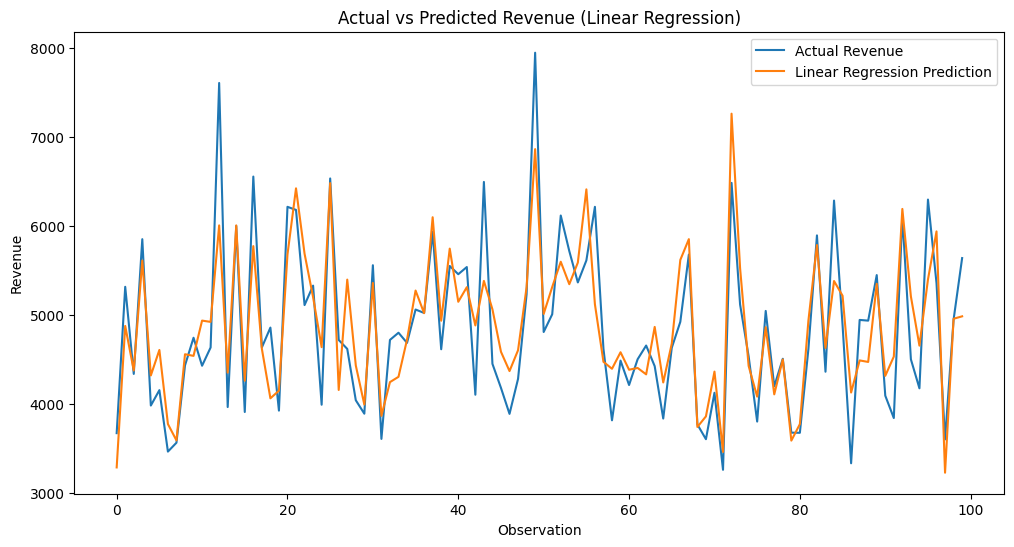

In [52]:
# ------------------------------------------------------------
# Step 16: Linear Regression Forecast Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:100],
    label="Actual Revenue"
)

plt.plot(
    linear_predictions[:100],
    label="Linear Regression Prediction"
)

plt.title(
    "Actual vs Predicted Revenue (Linear Regression)"
)

plt.xlabel("Observation")

plt.ylabel("Revenue")

plt.legend()

plt.show()

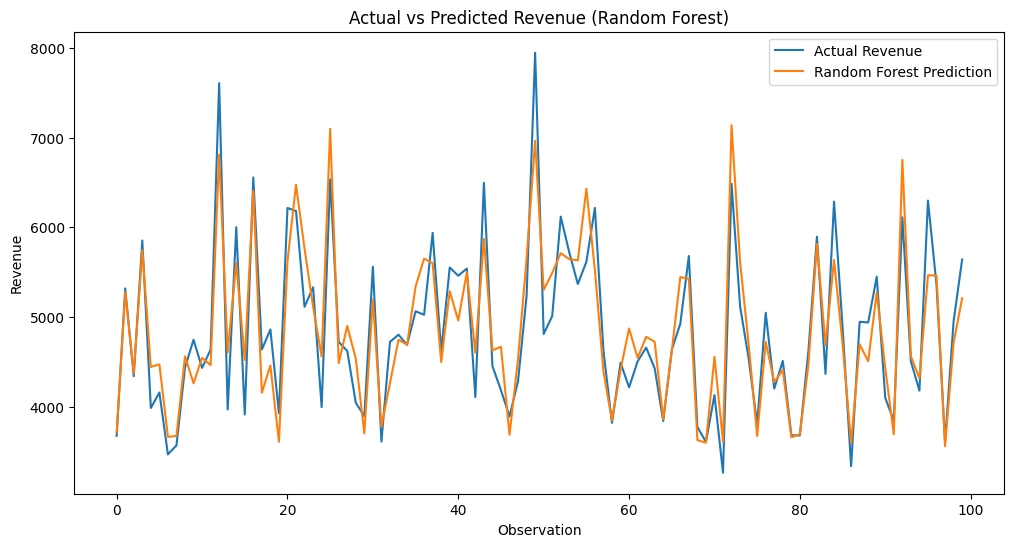

In [53]:
# ------------------------------------------------------------
# Step 17: Random Forest Forecast Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:100],
    label="Actual Revenue"
)

plt.plot(
    rf_predictions[:100],
    label="Random Forest Prediction"
)

plt.title(
    "Actual vs Predicted Revenue (Random Forest)"
)

plt.xlabel("Observation")

plt.ylabel("Revenue")

plt.legend()

plt.show()

In [54]:
# ------------------------------------------------------------
# Step 18: Feature Importance Analysis
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,temperature,0.46
3,month,0.21
1,is_weekend,0.11
5,day_of_week,0.09
6,search_frequency,0.08
2,is_holiday,0.04
4,quarter,0.01


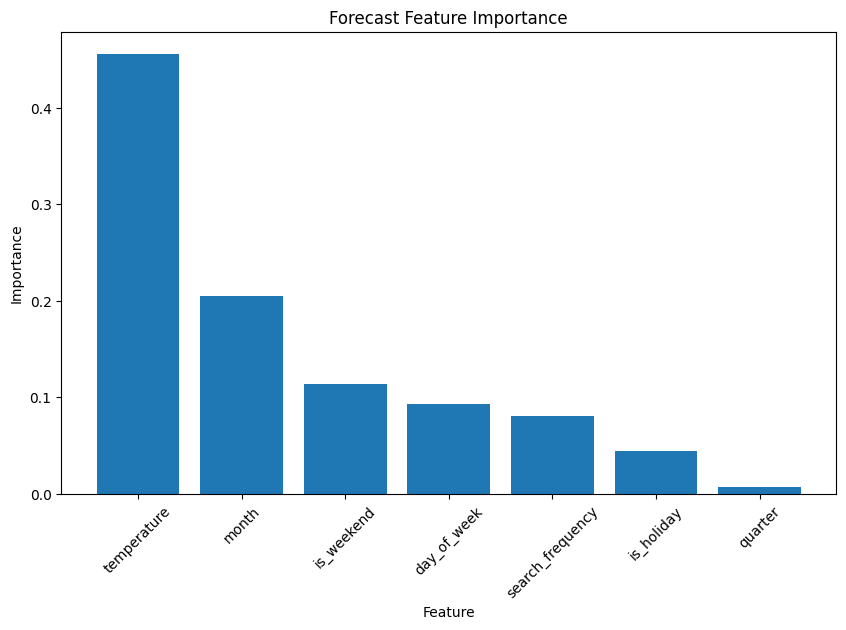

In [55]:
# ------------------------------------------------------------
# Step 19: Feature Importance Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Forecast Feature Importance")

plt.xlabel("Feature")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

## Forecasting Model Insights

Forecasting analysis indicates that seasonal variables, customer demand indicators, and operational calendar factors contributed meaningfully to marketplace revenue prediction performance.

The Random Forest model demonstrated stronger capability in capturing nonlinear marketplace behavior patterns relative to the baseline Linear Regression model.

Feature importance analysis suggests that:
- seasonal demand
- weekend activity
- temperature-related behavior
- search demand signals

all contributed to marketplace GMV fluctuations and predictive forecasting performance.

# Strategic Forecasting Recommendations

This section translates predictive modeling results into business recommendations that support marketplace growth, operational planning, and inventory optimization.

## Recommendation 1: Use Forecasting for Seasonal Inventory Planning

Forecasting results suggest that revenue behavior is influenced by seasonal and calendar-based factors. The marketplace should use predictive models to anticipate demand increases before peak seasons and adjust inventory planning accordingly.

## Recommendation 2: Prioritize High-Demand Time Windows

Weekend and seasonal demand patterns should be monitored closely because they can influence marketplace GMV and operational needs. These patterns may support better promotional timing and category prioritization.

## Recommendation 3: Combine Search Demand With Sales Forecasting

Search frequency can act as an early demand signal before purchases occur. Combining search trend data with historical sales data can improve marketplace forecasting and support more proactive planning.

# Final Forecasting Summary

This notebook demonstrated a predictive analytics workflow for forecasting daily marketplace revenue using synthetic ecommerce transaction data.

The workflow included:
- preparing daily revenue data
- engineering seasonal and demand-based features
- training Linear Regression and Random Forest models
- evaluating model performance
- interpreting feature importance
- translating predictions into business recommendations

Overall, this forecasting workflow shows how AI/ML concepts can support marketplace strategy, inventory planning, GMV forecasting, and operational decision-making.